# G4: TSTR Experiments (excellence task)

**Authors:** Ivo Rambaldi & Tommaso Petrelli

**Course:** Ethics in Artificial Intelligence, University of Bologna, a.y. 2025-2026

---

## Overview

Goal 4. We measure how training on synthetic data instead of real data changes utility and fairness, using Train on Synthetic, Test on Real (TSTR): every classifier is trained on one training set (the real baseline or one synthetic set) and evaluated on the same real held-out test set. Any change is then attributable to the training data alone.

Grid: 5 training sets (real, Gaussian Copula, CTGAN, TVAE, SMOTE) x 3 classifiers (Logistic Regression, XGBoost, MLP). Utility metrics: balanced accuracy, F1-macro, ROC-AUC, Brier, MMD. Fairness metrics (per protected attribute and averaged): DPD, EOD, DI. Hyperparameters are fixed across runs.

Metrics CSVs and figures are written to `results/experiments/` and `results/figures/`. The final cross-notebook interpretation is left to G5.

## 1. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Put the project root on sys.path so 'src' imports resolve.
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.logging import get_logger
from src.utils.prerequisites import check_prerequisites

logger = get_logger('notebook_04')
check_prerequisites()

logger.info(f"Environment ready. Project root: {PROJECT_ROOT}")

Prerequisites check (requirements.txt): 16 OK, 0 missing, 0 version-mismatched.
2026-07-25 05:17:58 | INFO     | notebook_04 | Environment ready. Project root: C:\Users\tomma\Desktop\petrellirambaldi2526


In [2]:
from src.utils.config import load_config
from src.data.persistence import ensure_dir

cfg = load_config(PROJECT_ROOT / 'config' / 'config.yaml')

# Route every saved figure/CSV to a dedicated mitigation/task sub-directory so
# this notebook (no mitigation applied) never overwrites G3's outputs (previously
# both wrote summary figures to the same results/figures/ path with the same names).
cfg['paths']['experiments_dir'] = cfg['paths']['results_dir'] / 'no_mitigation' / 'high_perf'
cfg['paths']['figures_dir']     = cfg['paths']['figures_dir'] / 'no_mitigation' / 'high_perf'

EXPERIMENTS_DIR = Path(cfg["paths"]["experiments_dir"])
FIGURES_DIR     = Path(cfg["paths"]["figures_dir"])
ensure_dir(EXPERIMENTS_DIR)
ensure_dir(FIGURES_DIR)

methods     = cfg["generation"]["methods"]
classifiers = [k for k, v in cfg["experiments"]["classifiers"].items() if v.get("enabled", True)]
protected   = cfg["dataset"]["protected_attributes"]

print('=== Configuration summary ===')
print(f"Seed                : {cfg['seed']}")
print(f"Generation methods  : {methods}")
print(f"Classifiers         : {classifiers}")
print(f"Protected attributes: {len(protected)}")
print(f"Total experiments   : {(len(methods) + 1) * len(classifiers)}")

=== Configuration summary ===
Seed                : 42
Generation methods  : {'ctgan': {'epochs': 300, 'batch_size': 500}, 'tvae': {'epochs': 300, 'batch_size': 500}, 'gaussian_copula': {'none': 0}, 'smote': {'k_neighbors': 5}}
Classifiers         : ['logistic_regression', 'xgboost', 'mlp']
Protected attributes: 12
Total experiments   : 15


## 2. Load data

Real train/test splits from G1, plus one synthetic training set per method from G2. The real test set is only ever used for evaluation.

In [3]:
from src.data.loader import load_real_data, load_synthetic_dataset

real_train_df, real_test_df = load_real_data(cfg)
logger.info(f"Real train: {real_train_df.shape}")
logger.info(f"Real test : {real_test_df.shape}")

# Excellence task: use the "smote" output, not the low-perf SMOTE variant.
METHODS = [m for m in cfg["generation"]["output_subdirs"].keys() if m != "smote_low_perf"]
synthetic_datasets = {m: load_synthetic_dataset(cfg, m) for m in METHODS}

for method, df in synthetic_datasets.items():
    logger.info(f"Synthetic [{method}]: {df.shape}")

2026-07-25 05:17:58 | INFO     | src.data.loader | Loading real train data from C:\Users\tomma\Desktop\petrellirambaldi2526\Data\train.csv


2026-07-25 05:17:58 | INFO     | src.data.loader | Loading real test data  from C:\Users\tomma\Desktop\petrellirambaldi2526\Data\test.csv


2026-07-25 05:17:59 | INFO     | notebook_04 | Real train: (58128, 48)


2026-07-25 05:17:59 | INFO     | notebook_04 | Real test : (14533, 48)


2026-07-25 05:17:59 | INFO     | src.data.loader | Loading synthetic data [ctgan] from C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\ctgan\synthetic_ctgan.csv


...

2026-07-25 05:17:59 | INFO     | src.data.loader | Loading synthetic data [smote] from C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\smote\synthetic_smote.csv


2026-07-25 05:18:00 | INFO     | notebook_04 | Synthetic [ctgan]: (58128, 48)


2026-07-25 05:18:00 | INFO     | notebook_04 | Synthetic [tvae]: (58128, 48)


2026-07-25 05:18:00 | INFO     | notebook_04 | Synthetic [gaussian_copula]: (58128, 48)


2026-07-25 05:18:00 | INFO     | notebook_04 | Synthetic [smote]: (87188, 48)


### 2.1 Class balance

Positive rates across the training sets. TVAE and SMOTE differ most from the real ~25%; classifiers absorb the imbalance via `class_weight` / `scale_pos_weight`.

In [4]:
rows = []
for label, df in {
    "real_train": real_train_df,
    "real_test":  real_test_df,
    **synthetic_datasets,
}.items():
    counts = df[cfg['dataset']['target_column']].value_counts(normalize=True)
    rows.append({
        "dataset":       label,
        "n_samples":     len(df),
        "positive_rate": round(counts.get(1, 0.0), 4),
        "negative_rate": round(counts.get(0, 0.0), 4),
    })

dist_df = pd.DataFrame(rows)
display(dist_df)

,dataset,n_samples,positive_rate,negative_rate
0,real_train,58128,0.2500,0.7500
1,real_test,14533,0.2438,0.7562
2,ctgan,58128,0.2445,0.7555
3,tvae,58128,0.2361,0.7639
4,gaussian_copula,58128,0.2506,0.7494
5,smote,87188,0.5000,0.5000


## 3. TSTR matrix

Every (training set, classifier) pair runs through a shared `Evaluator`: it fits the classifier (features encoded with an OrdinalEncoder + StandardScaler fit on the real train set), predicts on the real test set, and computes utility, per-attribute and mean fairness, MMD and correlation deltas. `baseline()` anchors the real reference per classifier; `evaluate()` scores a synthetic set against it.

In [5]:
from src.data.preprocessing import get_feature_columns
from src.data.preprocessor import DataSplit, fit_feature_encoders, apply_feature_encoders
from src.evaluation.evaluator import Evaluator
from src.models.classifiers import CLASSIFIER_DISPLAY_NAMES

target_col      = cfg["dataset"]["target_column"]
protected_attrs = cfg["dataset"]["protected_attributes"]

# Feature set and encoders are fit once on the real train set and reused for the
# real test set and every synthetic set (LogReg/MLP need numerical input).
feature_columns = get_feature_columns(real_train_df, cfg)
logger.info(
    f"Feature set: {len(feature_columns)} columns derived from real training data."
)

enc, scaler, cat_cols, num_cols = fit_feature_encoders(real_train_df[feature_columns])

X_train_real = apply_feature_encoders(real_train_df[feature_columns], enc, scaler, cat_cols, num_cols)
X_test_real  = apply_feature_encoders(real_test_df[feature_columns],  enc, scaler, cat_cols, num_cols)

present_protected = [a for a in protected_attrs if a in real_train_df.columns]
missing_protected = [a for a in protected_attrs if a not in real_train_df.columns]
if missing_protected:
    logger.warning(
        f"{len(missing_protected)} configured protected attributes not present "
        f"in the data - skipping: {missing_protected}"
    )

split = DataSplit(
    X_train         = X_train_real,
    X_test          = X_test_real,
    y_train         = real_train_df[target_col].astype(int),
    y_test          = real_test_df[target_col].astype(int),
    protected_train = real_train_df[present_protected].copy(),
    protected_test  = real_test_df[present_protected].copy(),
    feature_names   = feature_columns,
    target_name     = target_col,
    protected_attrs = present_protected,
    encoders        = {"ordinal": enc},
    scaler          = scaler,
)

evaluator = Evaluator(split, cfg)
print(f"DataSplit ready. X_train={split.X_train.shape}  X_test={split.X_test.shape}  "
      f"protected={len(present_protected)}")

2026-07-25 05:18:00 | INFO     | notebook_04 | Feature set: 46 columns derived from real training data.


DataSplit ready. X_train=(58128, 46)  X_test=(14533, 46)  protected=12


In [6]:
classifiers    = list(cfg["experiments"]["classifiers"].keys())
baseline_label = cfg["experiments"]["baseline_label"]

rows = []
per_attr_fairness = {baseline_label: {}, **{m: {} for m in synthetic_datasets}}

# Classifier-outer / method-inner so baseline() anchors the real reference first.
for clf_name in classifiers:
    logger.info(f"==> [{baseline_label} | {CLASSIFIER_DISPLAY_NAMES[clf_name]}]")
    result = evaluator.baseline(clf_name)
    result = {**result, "mmd": 0.0}  # MMD(real, real) = 0 by definition
    per_attr_fairness[baseline_label][clf_name] = evaluator.last_fairness_detail
    rows.append({"method": baseline_label, "classifier": clf_name, **result})

    for method, syn_df in synthetic_datasets.items():
        logger.info(f"==> [{method} | {CLASSIFIER_DISPLAY_NAMES[clf_name]}]")

        missing = [c for c in feature_columns if c not in syn_df.columns]
        if missing:
            logger.warning(f"  [{method}] {len(missing)} feature cols absent - filled with 0.")
        X_synth_raw = pd.DataFrame(
            {c: syn_df[c] if c in syn_df.columns else 0.0 for c in feature_columns},
            index=syn_df.index,
        )
        X_synth = apply_feature_encoders(X_synth_raw, enc, scaler, cat_cols, num_cols)
        y_synth = syn_df[target_col].astype(int)

        result = evaluator.evaluate(
            X_synth         = X_synth,
            y_synth         = y_synth,
            classifier_name = clf_name,
            generator_name  = method,
            X_real_for_mmd  = split.X_train,
        )
        per_attr_fairness[method][clf_name] = evaluator.last_fairness_detail
        rows.append({"method": result.pop("generator"), "classifier": result.pop("classifier"), **result})

metrics_df = pd.DataFrame(rows)

# Reorder columns for readability.
id_cols    = ["method", "classifier"]
util_cols  = [
    c for c in ["balanced_accuracy", "f1_macro", "roc_auc", "brier_score", "mmd"]
    if c in metrics_df.columns
]
fair_cols  = [c for c in metrics_df.columns if c.startswith("mean_")]
extra_cols = [c for c in metrics_df.columns if c not in id_cols + util_cols + fair_cols]
metrics_df = metrics_df[id_cols + util_cols + fair_cols + extra_cols]

logger.info(f"Experiment matrix complete. Shape: {metrics_df.shape}")
display(metrics_df)

2026-07-25 05:18:01 | INFO     | notebook_04 | ==> [real | Logistic Regression]


2026-07-25 05:18:01 | INFO     | src.evaluation.evaluator | Computing real-data baseline for [logistic_regression] …


2026-07-25 05:18:02 | INFO     | src.evaluation.evaluator |   [real] AUC=0.6774 | BA=0.6264


2026-07-25 05:18:02 | INFO     | notebook_04 | ==> [ctgan | Logistic Regression]


2026-07-25 05:18:02 | INFO     | src.evaluation.evaluator | Evaluating [ctgan | logistic_regression | rep=0] …


...

2026-07-25 05:19:44 | INFO     | notebook_04 | ==> [smote | MLP]


2026-07-25 05:19:44 | INFO     | src.evaluation.evaluator | Evaluating [smote | mlp | rep=0] …


2026-07-25 05:20:52 | INFO     | src.evaluation.evaluator |   [synthetic] AUC=0.5660 | BA=0.5630


2026-07-25 05:20:56 | INFO     | notebook_04 | Experiment matrix complete. Shape: (15, 66)


,method,classifier,balanced_accuracy,f1_macro,roc_auc,brier_score,mmd,mean_dpd,mean_eod,mean_di,...,f_ESCS_dpd,f_ESCS_eod,f_ESCS_di,f_ESCS_odds_ratio,repetition,delta_balanced_accuracy,delta_f1_macro,delta_roc_auc,corr_mean_abs_delta,corr_max_abs_delta
0,real,logistic_regression,0.626449,0.593596,0.677418,0.224966,0.000000,0.352740,0.356601,0.480914,...,0.492382,0.473519,0.307145,0.426708,NaN,NaN,NaN,NaN,NaN,NaN
1,ctgan,logistic_regression,0.565316,0.523645,0.593856,0.244407,0.003424,0.279654,0.293592,0.593529,...,0.413435,0.434998,0.439039,0.449937,0.0,0.061133,0.069951,0.083561,0.068883,0.696556
2,tvae,logistic_regression,0.604171,0.599544,0.655409,0.218690,0.024449,0.381024,0.408348,0.355642,...,0.584627,0.638154,0.095269,0.151053,0.0,0.022277,-0.005948,0.022008,0.056135,0.684763
3,gaussian_copula,logistic_regression,0.432486,0.418851,0.403056,0.251838,0.002459,0.270140,0.279945,0.518517,...,0.375834,0.370023,0.375140,2.919956,0.0,0.193963,0.174745,0.274362,0.074673,0.864309
4,smote,logistic_regression,0.609108,0.562140,0.664906,0.231181,0.001972,0.270669,0.265300,0.600356,...,0.331742,0.315783,0.507014,0.597805,0.0,0.017340,0.031456,0.012512,0.019385,0.669772
5,real,xgboost,0.654336,0.618162,0.714586,0.213914,0.000000,0.354172,0.358438,0.483655,...,0.516937,0.504034,0.284804,0.485476,NaN,NaN,NaN,NaN,NaN,NaN
6,ctgan,xgboost,0.538848,0.505369,0.554122,0.242362,0.003424,0.165671,0.182223,0.717238,...,0.239564,0.275369,0.610043,0.581970,0.0,0.115487,0.112792,0.160464,0.068883,0.696556
7,tvae,xgboost,0.613691,0.601974,0.658051,0.220247,0.024449,0.378560,0.399599,0.400773,...,0.593103,0.591728,0.137573,0.240315,0.0,0.040645,0.016187,0.056536,0.056135,0.684763
8,gaussian_copula,xgboost,0.448182,0.412073,0.432326,0.252318,0.002459,0.158779,0.158473,0.731419,...,0.241918,0.236215,0.618672,1.632055,0.0,0.206154,0.206089,0.282261,0.074673,0.864309
9,smote,xgboost,0.529342,0.502601,0.555443,0.350731,0.001972,0.097308,0.171102,0.806558,...,0.188038,0.239025,0.630194,1.231046,0.0,0.124993,0.115560,0.159143,0.019385,0.669772


### 3.1 Save the results matrix

In [7]:
from src.data.persistence import save_csv


metrics_path = EXPERIMENTS_DIR / "metrics_matrix.csv"
save_csv(metrics_df, metrics_path)
logger.info(f"Metrics matrix saved to: {metrics_path}")

2026-07-25 05:20:56 | INFO     | src.data.persistence | Saved CSV to C:\Users\tomma\Desktop\petrellirambaldi2526\results\no_mitigation\high_perf\metrics_matrix.csv


2026-07-25 05:20:56 | INFO     | notebook_04 | Metrics matrix saved to: C:\Users\tomma\Desktop\petrellirambaldi2526\results\no_mitigation\high_perf\metrics_matrix.csv


## 4. Delta Analysis

The quantity of interest is the change from the real baseline, per classifier: `delta = metric(method, clf) - metric(real, clf)`. Comparing each synthetic model against the real model of the same classifier removes classifier effects. For higher-is-better metrics (balanced accuracy, F1, AUC, DI) a negative delta is degradation; for lower-is-better ones (Brier, DPD, EOD) a positive delta is degradation.

In [8]:
from src.evaluation.delta import (
    compute_delta_matrix,
    get_utility_delta_columns,
    get_fairness_delta_columns,
)

delta_df = compute_delta_matrix(metrics_df, cfg)

baseline_label = cfg["experiments"]["baseline_label"]
delta_syn = delta_df[delta_df["method"] != baseline_label].copy()

util_delta_cols  = get_utility_delta_columns(delta_df)
fair_delta_cols  = get_fairness_delta_columns(delta_df)

logger.info(f"Utility delta columns: {util_delta_cols}")
logger.info(f"Fairness delta columns: {fair_delta_cols}")
display(delta_syn[["method", "classifier"] + util_delta_cols + fair_delta_cols])

2026-07-25 05:20:56 | INFO     | notebook_04 | Utility delta columns: ['delta_balanced_accuracy', 'delta_f1_macro', 'delta_roc_auc', 'delta_brier_score', 'delta_mmd']


2026-07-25 05:20:56 | INFO     | notebook_04 | Fairness delta columns: ['delta_mean_dpd', 'delta_mean_eod', 'delta_mean_di', 'delta_mean_odds_ratio']


,method,classifier,delta_balanced_accuracy,delta_f1_macro,delta_roc_auc,delta_brier_score,delta_mmd,delta_mean_dpd,delta_mean_eod,delta_mean_di,delta_mean_odds_ratio
1,ctgan,logistic_regression,-0.061133,-0.069951,-0.083561,0.019441,0.003424,-0.073086,-0.063010,0.112615,0.216119
2,tvae,logistic_regression,-0.022277,0.005948,-0.022008,-0.006276,0.024449,0.028284,0.051746,-0.125271,-0.055350
3,gaussian_copula,logistic_regression,-0.193963,-0.174745,-0.274362,0.026871,0.002459,-0.082600,-0.076657,0.037604,1.045394
4,smote,logistic_regression,-0.017340,-0.031456,-0.012512,0.006215,0.001972,-0.082071,-0.091301,0.119442,0.014101
6,ctgan,xgboost,-0.115487,-0.112792,-0.160464,0.028448,0.003424,-0.188501,-0.176216,0.233583,0.173803
7,tvae,xgboost,-0.040645,-0.016187,-0.056536,0.006333,0.024449,0.024387,0.041161,-0.082882,0.056323
8,gaussian_copula,xgboost,-0.206154,-0.206089,-0.282261,0.038404,0.002459,-0.195394,-0.199965,0.247764,0.526167
9,smote,xgboost,-0.124993,-0.115560,-0.159143,0.136817,0.001972,-0.256864,-0.187337,0.322904,0.193274
11,ctgan,mlp,-0.066257,-0.133161,-0.132983,0.018535,0.003424,-0.097258,-0.142752,NaN,NaN
12,tvae,mlp,0.021144,0.028600,-0.041215,0.036244,0.024449,0.210501,0.213937,-0.040477,0.361862


In [9]:
# Save the delta matrix to CSV
delta_path = EXPERIMENTS_DIR / "delta_matrix.csv"
save_csv(delta_df, delta_path)
logger.info(f"Delta matrix saved to: {delta_path}")

2026-07-25 05:20:56 | INFO     | src.data.persistence | Saved CSV to C:\Users\tomma\Desktop\petrellirambaldi2526\results\no_mitigation\high_perf\delta_matrix.csv


2026-07-25 05:20:56 | INFO     | notebook_04 | Delta matrix saved to: C:\Users\tomma\Desktop\petrellirambaldi2526\results\no_mitigation\high_perf\delta_matrix.csv


### 4.1 Per-attribute fairness

One CSV per (method, classifier) with the full per-protected-attribute breakdown, used for the drill-down in 5.6.

In [10]:
per_attr_dir = EXPERIMENTS_DIR / "per_attribute_fairness"
ensure_dir(per_attr_dir)

for method, clf_dict in per_attr_fairness.items():
    for clf_name, fair_df in clf_dict.items():
        filename = f"fairness_{method}_{clf_name}.csv"
        save_csv(fair_df, per_attr_dir / filename)

logger.info(f"Per-attribute fairness CSVs saved to: {per_attr_dir}")

2026-07-25 05:20:56 | INFO     | src.data.persistence | Saved CSV to C:\Users\tomma\Desktop\petrellirambaldi2526\results\no_mitigation\high_perf\per_attribute_fairness\fairness_real_logistic_regression.csv


2026-07-25 05:20:56 | INFO     | src.data.persistence | Saved CSV to C:\Users\tomma\Desktop\petrellirambaldi2526\results\no_mitigation\high_perf\per_attribute_fairness\fairness_real_xgboost.csv


2026-07-25 05:20:56 | INFO     | src.data.persistence | Saved CSV to C:\Users\tomma\Desktop\petrellirambaldi2526\results\no_mitigation\high_perf\per_attribute_fairness\fairness_real_mlp.csv


2026-07-25 05:20:56 | INFO     | src.data.persistence | Saved CSV to C:\Users\tomma\Desktop\petrellirambaldi2526\results\no_mitigation\high_perf\per_attribute_fairness\fairness_ctgan_logistic_regression.csv


2026-07-25 05:20:56 | INFO     | src.data.persistence | Saved CSV to C:\Users\tomma\Desktop\petrellirambaldi2526\results\no_mitigation\high_perf\per_attribute_fairness\fairness_ctgan_xgboost.csv


...

2026-07-25 05:20:56 | INFO     | src.data.persistence | Saved CSV to C:\Users\tomma\Desktop\petrellirambaldi2526\results\no_mitigation\high_perf\per_attribute_fairness\fairness_gaussian_copula_mlp.csv


2026-07-25 05:20:56 | INFO     | src.data.persistence | Saved CSV to C:\Users\tomma\Desktop\petrellirambaldi2526\results\no_mitigation\high_perf\per_attribute_fairness\fairness_smote_logistic_regression.csv


2026-07-25 05:20:56 | INFO     | src.data.persistence | Saved CSV to C:\Users\tomma\Desktop\petrellirambaldi2526\results\no_mitigation\high_perf\per_attribute_fairness\fairness_smote_xgboost.csv


2026-07-25 05:20:56 | INFO     | src.data.persistence | Saved CSV to C:\Users\tomma\Desktop\petrellirambaldi2526\results\no_mitigation\high_perf\per_attribute_fairness\fairness_smote_mlp.csv


2026-07-25 05:20:56 | INFO     | notebook_04 | Per-attribute fairness CSVs saved to: C:\Users\tomma\Desktop\petrellirambaldi2526\results\no_mitigation\high_perf\per_attribute_fairness


## 5. Figures

### 5.1 Maximum Mean Discrepancy

Distance between synthetic and real training features (RBF kernel, lower is better). Independent of the classifier.

2026-07-25 05:20:57 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\no_mitigation\high_perf\mmd_comparison.png


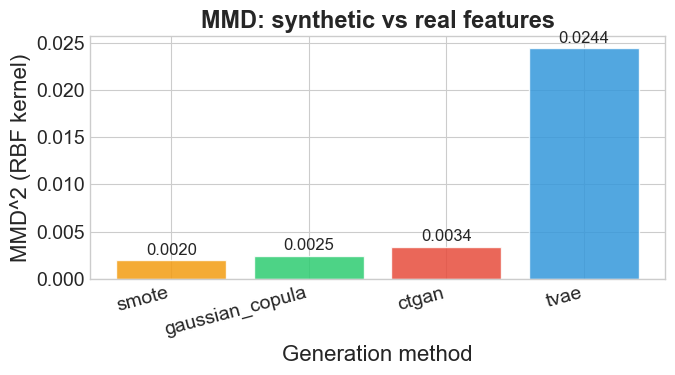

In [11]:
from src.utils.plotting import plot_mmd_bar


fig_mmd = plot_mmd_bar(metrics_df, cfg, save=True)
plt.show(); plt.close()

### 5.2 Utility

Absolute utility per (method, classifier); the real baseline is shown first. Balanced accuracy is the primary metric given the class imbalance.

2026-07-25 05:20:57 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\no_mitigation\high_perf\utility_balanced_accuracy.png


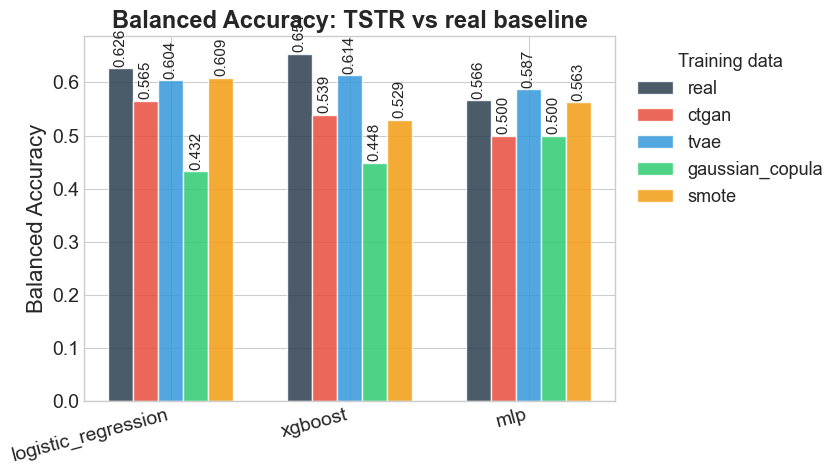

2026-07-25 05:20:57 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\no_mitigation\high_perf\utility_f1_macro.png


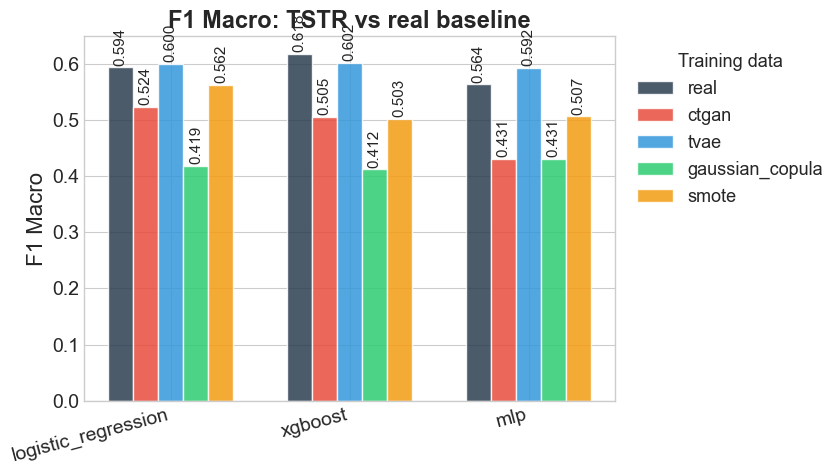

2026-07-25 05:20:58 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\no_mitigation\high_perf\utility_roc_auc.png


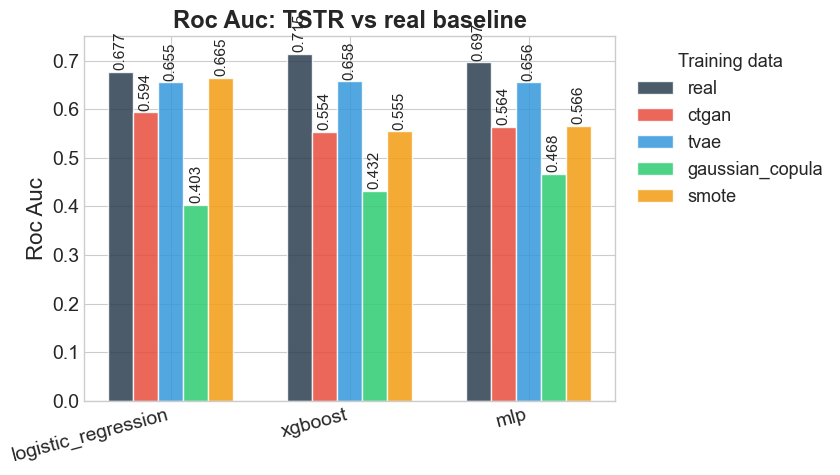

In [12]:
from src.utils.plotting import plot_utility_bar


utility_metric_cols = [
    m for m in cfg["experiments"]["utility_metrics"] if m != "mmd" and m in metrics_df.columns
]

for metric in utility_metric_cols:
    fig = plot_utility_bar(metrics_df, metric=metric, cfg=cfg, save=True)
    plt.show(); plt.close()

### 5.3 Fairness

Mean over the 8 available protected attributes. DPD and EOD: lower is fairer (0 = parity). DI: higher is fairer (below 0.8 fails the four-fifths rule).

2026-07-25 05:20:58 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\no_mitigation\high_perf\fairness_mean_dpd.png


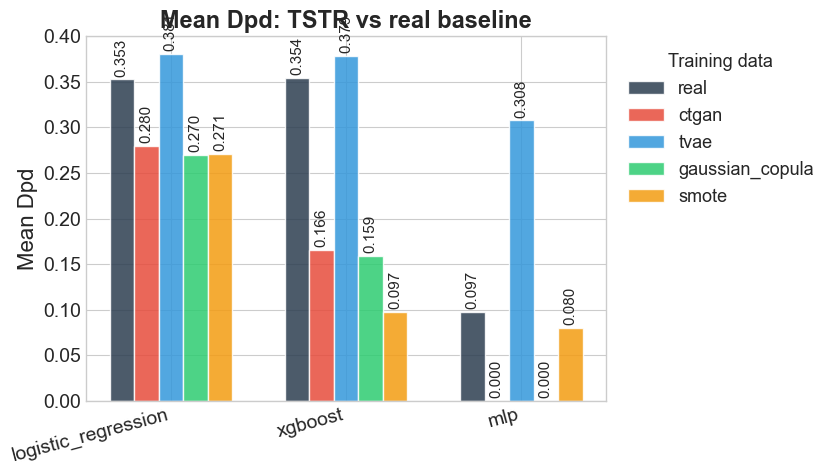

2026-07-25 05:20:59 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\no_mitigation\high_perf\fairness_mean_eod.png


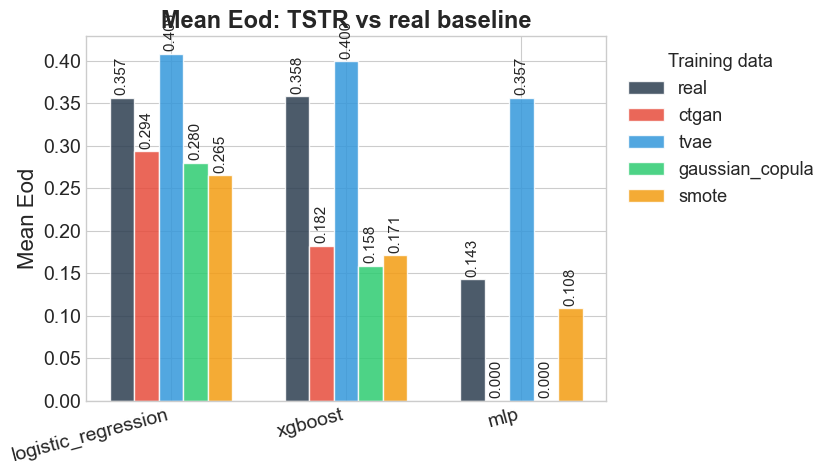

2026-07-25 05:20:59 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\no_mitigation\high_perf\fairness_mean_di.png


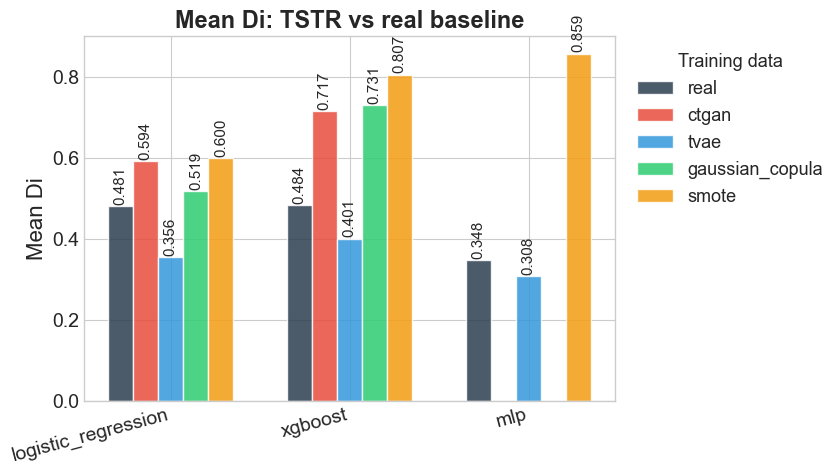

2026-07-25 05:20:59 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\no_mitigation\high_perf\fairness_mean_odds_ratio.png


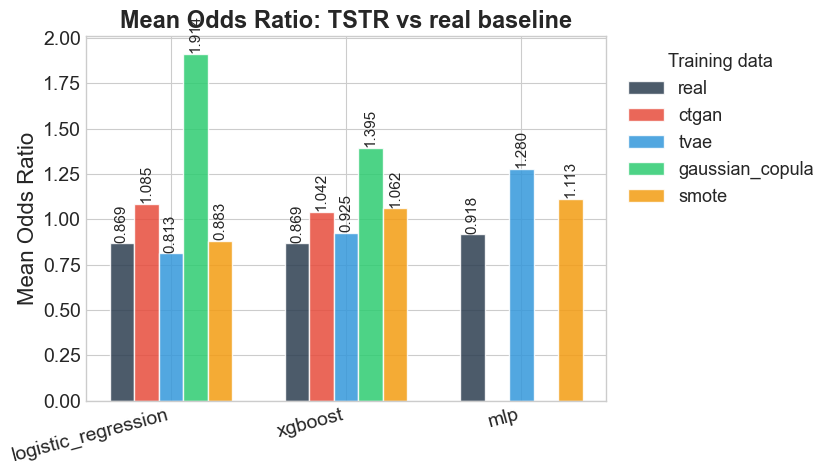

In [13]:
from src.utils.plotting import plot_fairness_bar


fairness_summary_cols = [c for c in metrics_df.columns if c.startswith("mean_")]

for metric in fairness_summary_cols:
    fig = plot_fairness_bar(metrics_df, metric=metric, cfg=cfg, save=True)
    plt.show(); plt.close()

### 5.4 Delta heatmaps

Change from the real baseline per classifier. Red = worse than real, blue = better.

2026-07-25 05:21:00 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\no_mitigation\high_perf\delta_heatmap_utility.png


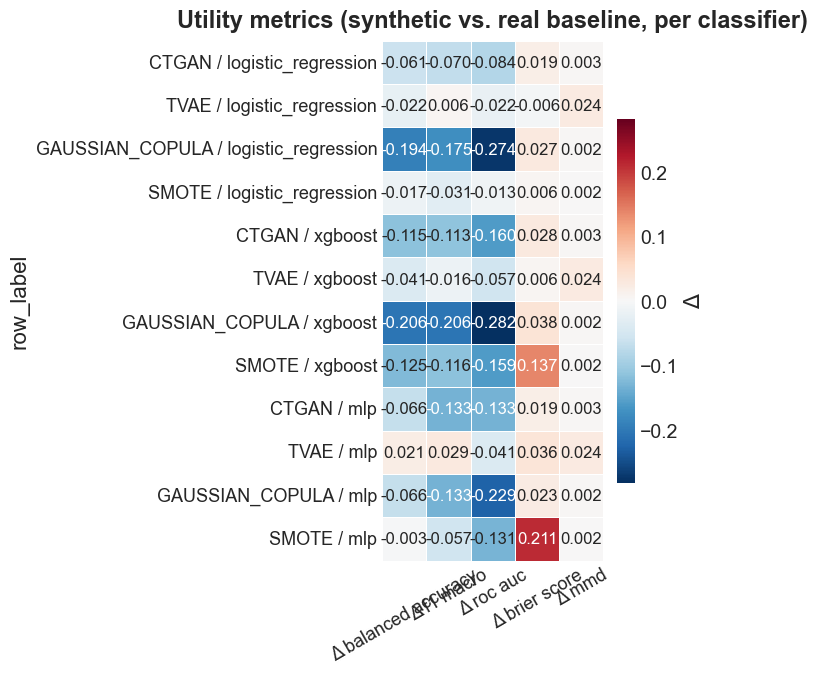

2026-07-25 05:21:01 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\no_mitigation\high_perf\delta_heatmap_fairness.png


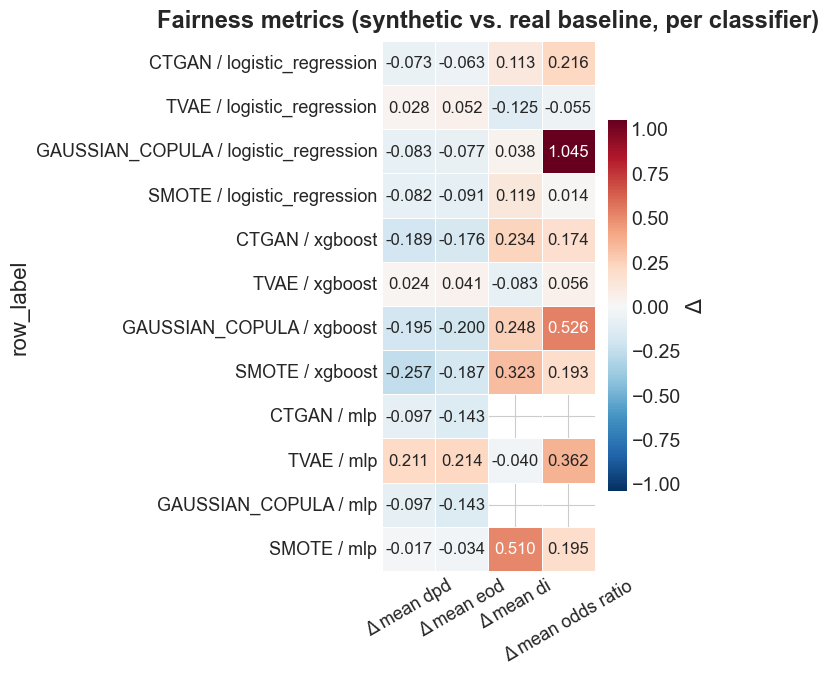

In [14]:
from src.utils.plotting import plot_delta_heatmap


# Utility delta heatmap
if util_delta_cols:
    fig = plot_delta_heatmap(
        delta_df,
        delta_columns=util_delta_cols,
        filename_suffix="utility",
        cfg=cfg,
        title="Utility metrics (synthetic vs. real baseline, per classifier)",
        save=True
    )
    plt.show(); plt.close()

# Fairness delta heatmap
if fair_delta_cols:
    fig = plot_delta_heatmap(
        delta_df,
        delta_columns=fair_delta_cols,
        filename_suffix="fairness",
        cfg=cfg,
        title="Fairness metrics (synthetic vs. real baseline, per classifier)",
        save=True
    )
    plt.show(); plt.close()

### 5.5 Utility loss vs fairness change

Does losing utility go together with losing fairness? Each point is a (method, classifier) pair on the balanced-accuracy-delta / mean-DPD-delta plane; the origin is the real baseline.

2026-07-25 05:21:01 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\no_mitigation\high_perf\scatter_utility_vs_fairness.png


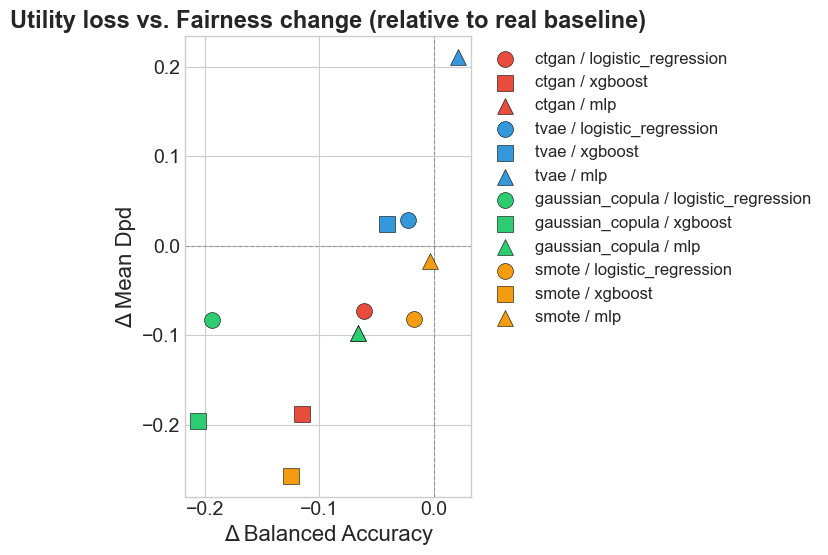

In [15]:
from src.utils.plotting import plot_utility_fairness_scatter


# Use balanced accuracy (primary utility metric) and mean DPD (primary fairness metric).
util_scatter_col = "delta_balanced_accuracy"
fair_scatter_col = "delta_mean_dpd"

if util_scatter_col in delta_df.columns and fair_scatter_col in delta_df.columns:
    fig = plot_utility_fairness_scatter(
        delta_df,
        utility_col=util_scatter_col,
        fairness_col=fair_scatter_col,
        cfg=cfg,
        save=True
    )
    plt.show(); plt.close()
else:
    logger.warning(
        f"Scatter requires '{util_scatter_col}' and '{fair_scatter_col}'. "
        "Check that balanced_accuracy and mean_dpd are in the metrics config."
    )

### 5.6 Per-attribute fairness

For each method we drill into the classifier with the worst mean DPD and show the three headline metrics (DPD, EOD, DI) per protected attribute, to see which circumstances (parental education, ESCS, ...) drive the aggregate numbers.

How to read: each bar is the size of the gap between the two groups of a circumstance. For DPD and EOD lower is fairer (green, left of the 0.1 line); for DI higher is fairer (green, right of the 0.8 four-fifths line). Gender stays near-fair across methods, while the socioeconomic circumstances (parental education, ESCS, books, occupation) drive the disparity.

2026-07-25 05:21:02 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\no_mitigation\high_perf\per_attr_dpd_ctgan_logistic_regression.png


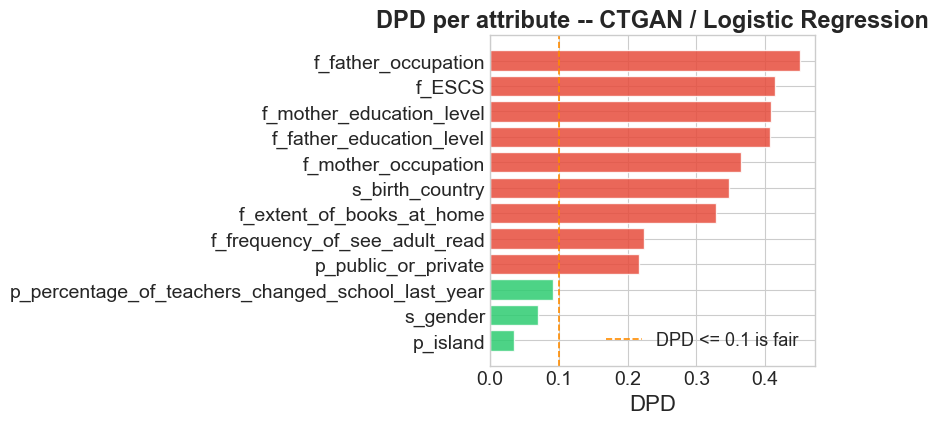

2026-07-25 05:21:02 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\no_mitigation\high_perf\per_attr_eod_ctgan_logistic_regression.png


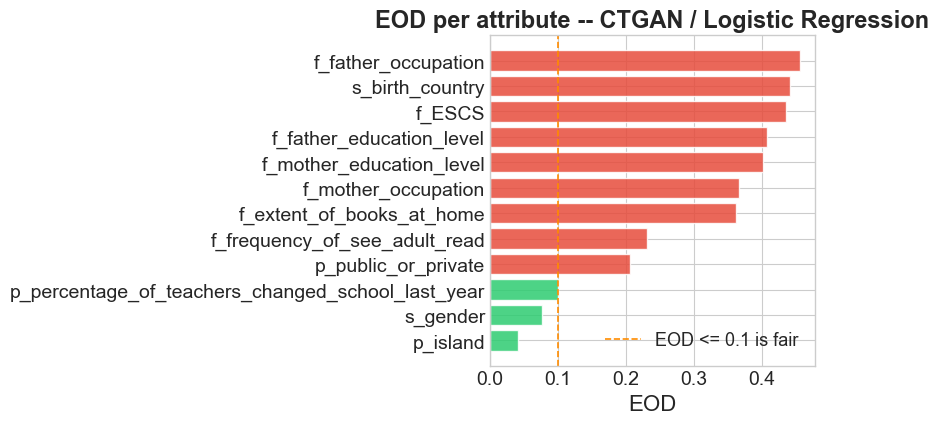

2026-07-25 05:21:02 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\no_mitigation\high_perf\per_attr_di_ctgan_logistic_regression.png


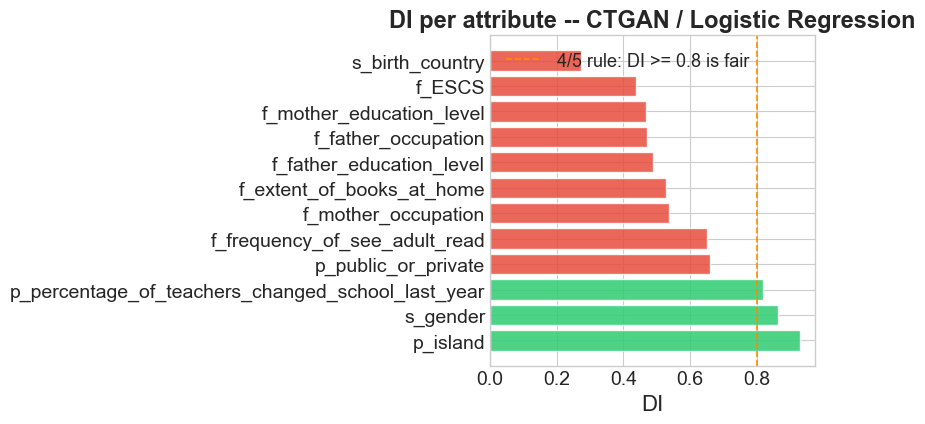

2026-07-25 05:21:03 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\no_mitigation\high_perf\per_attr_dpd_tvae_logistic_regression.png


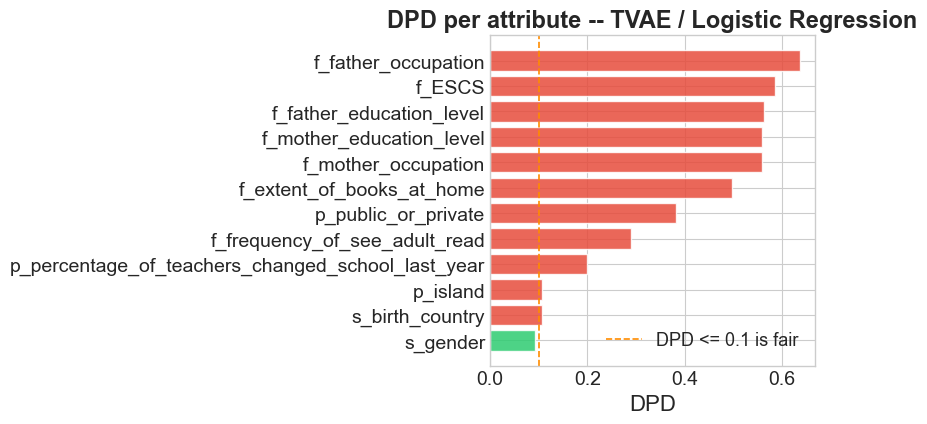

2026-07-25 05:21:03 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\no_mitigation\high_perf\per_attr_eod_tvae_logistic_regression.png


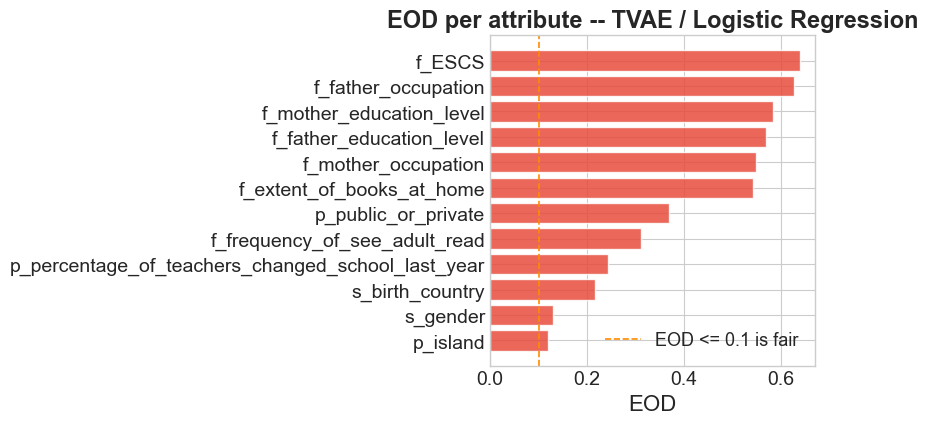

2026-07-25 05:21:03 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\no_mitigation\high_perf\per_attr_di_tvae_logistic_regression.png


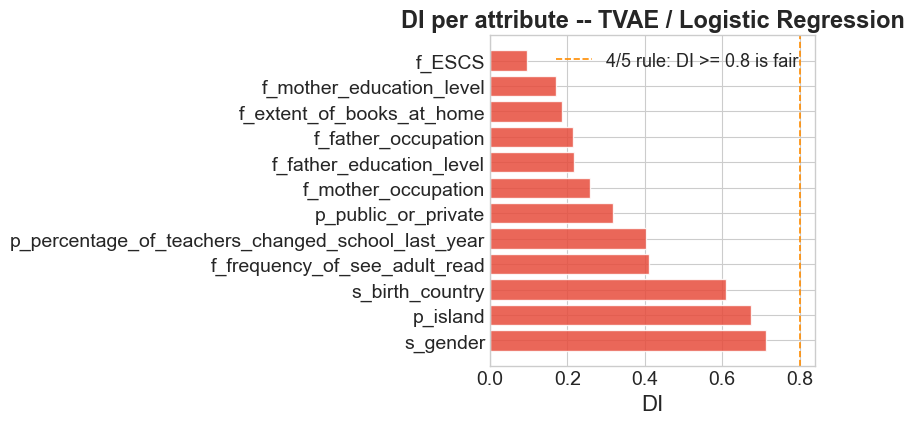

2026-07-25 05:21:04 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\no_mitigation\high_perf\per_attr_dpd_gaussian_copula_logistic_regression.png


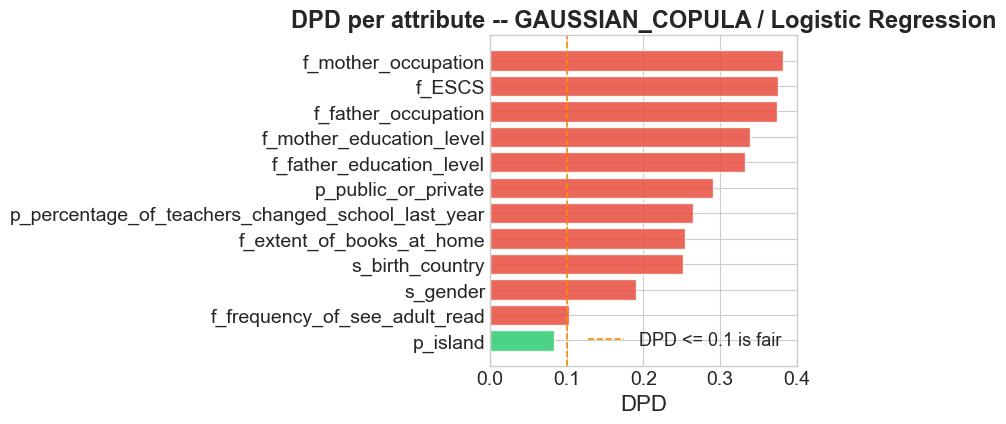

2026-07-25 05:21:04 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\no_mitigation\high_perf\per_attr_eod_gaussian_copula_logistic_regression.png


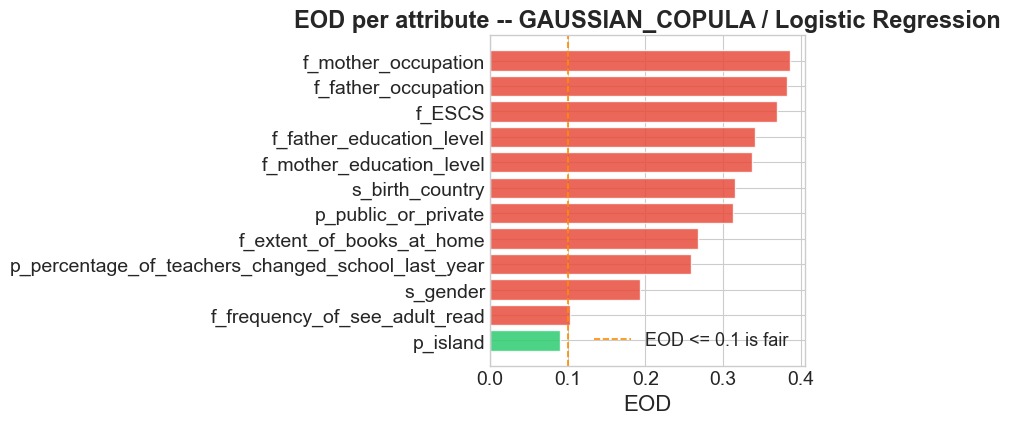

2026-07-25 05:21:05 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\no_mitigation\high_perf\per_attr_di_gaussian_copula_logistic_regression.png


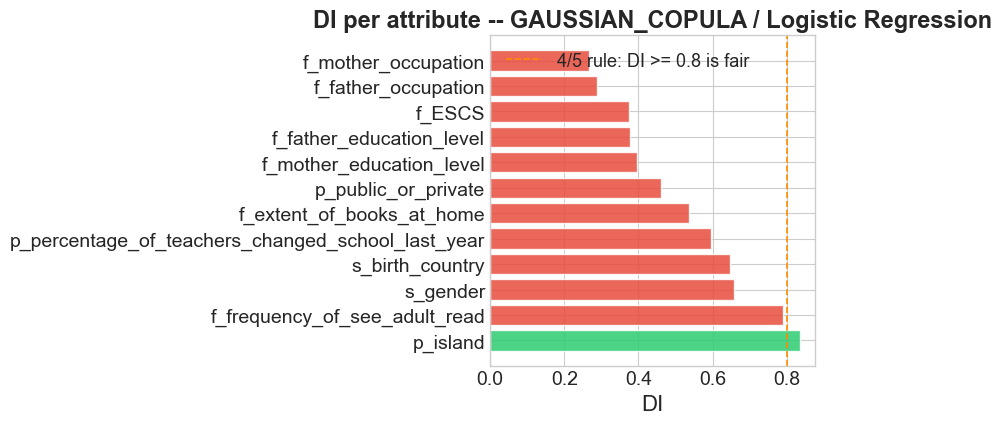

2026-07-25 05:21:05 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\no_mitigation\high_perf\per_attr_dpd_smote_logistic_regression.png


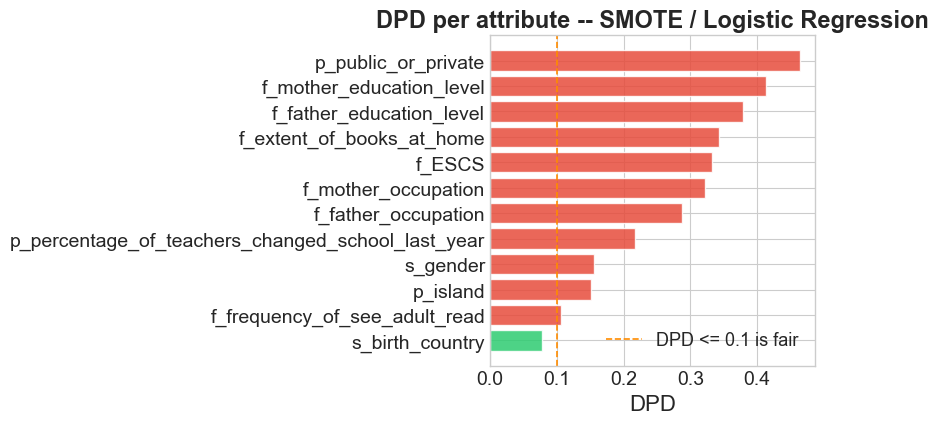

2026-07-25 05:21:05 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\no_mitigation\high_perf\per_attr_eod_smote_logistic_regression.png


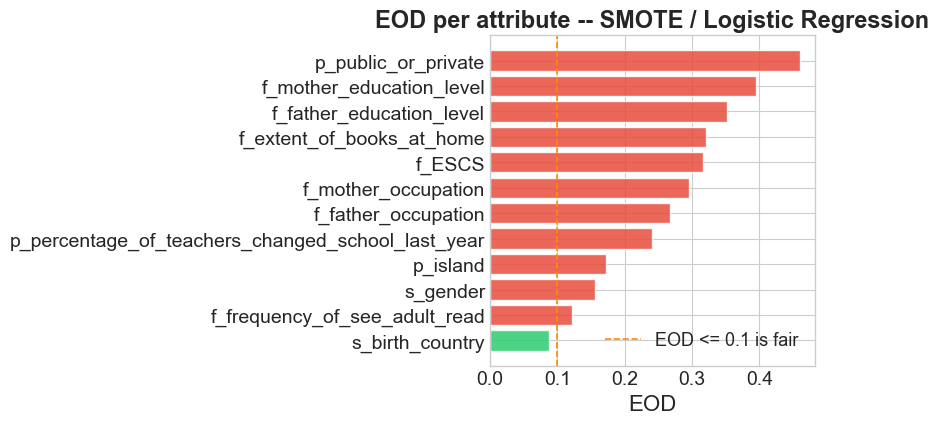

2026-07-25 05:21:06 | INFO     | src.utils.plotting | Figure saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\no_mitigation\high_perf\per_attr_di_smote_logistic_regression.png


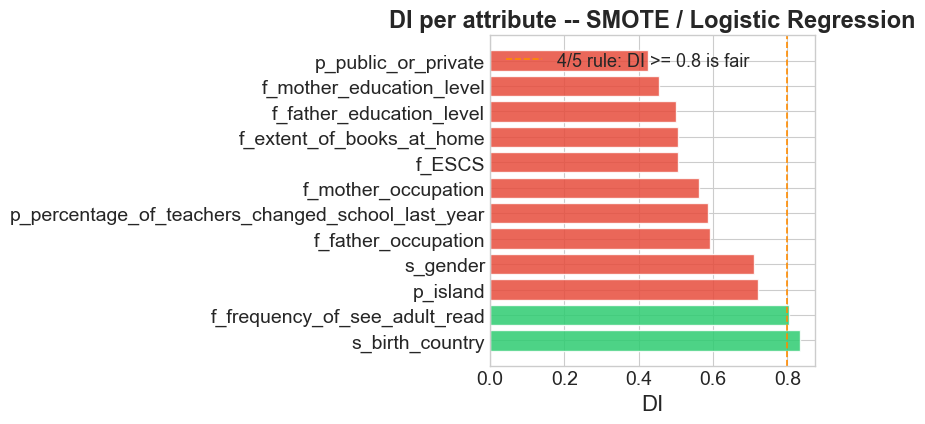

In [16]:
from src.utils.plotting import plot_per_attribute_fairness

# For each method, drill into the classifier with the worst mean DPD and show the
# three headline fairness metrics (DPD, EOD, DI) per protected attribute.
for method in cfg["generation"]["methods"]:
    method_rows = metrics_df[metrics_df["method"] == method]
    worst_clf = method_rows.loc[method_rows["mean_dpd"].idxmax(), "classifier"]
    fair_df   = per_attr_fairness[method].get(worst_clf)

    for fairness_metric in ["dpd", "eod", "di"]:
        title = (
            f"{fairness_metric.upper()} per attribute -- "
            f"{method.upper()} / {worst_clf.replace('_', ' ').title()}"
        )
        fig = plot_per_attribute_fairness(
            fair_df,
            metric    = fairness_metric,
            cfg       = cfg,
            title     = title,
            save = True,
            filename_suffix = f"_{method}_{worst_clf}"
        )
        plt.show(); plt.close()

## 6. Summary tables

### 6.1 Utility by method

Utility averaged across classifiers, per method.

In [17]:
util_cols = [
    m for m in list(metrics_df.columns)
    if m not in ("method", "classifier", "mmd")
    and pd.api.types.is_numeric_dtype(metrics_df[m])
]

utility_summary = metrics_df.groupby("method")[util_cols].mean().round(4)

# Add MMD column (method-level, not classifier-level).
utility_summary["mmd"] = metrics_df.groupby("method")["mmd"].first().round(4)

display(utility_summary)

save_csv(utility_summary.reset_index(), EXPERIMENTS_DIR / "utility_summary.csv")

,balanced_accuracy,f1_macro,roc_auc,brier_score,mean_dpd,mean_eod,mean_di,mean_odds_ratio,degenerate_predictions,s_gender_dpd,...,f_ESCS_eod,f_ESCS_di,f_ESCS_odds_ratio,repetition,delta_balanced_accuracy,delta_f1_macro,delta_roc_auc,corr_mean_abs_delta,corr_max_abs_delta,mmd
method,,,,,,,,,,,,,,,,,,,,,
ctgan,0.5347,0.4865,0.5707,0.2236,0.1484,0.1586,0.6554,1.0635,0.3333,0.0242,...,0.2368,0.5245,0.5160,0.0,0.0810,0.1053,0.1257,0.0689,0.6966,0.0034
gaussian_copula,0.4602,0.4205,0.4344,0.2308,0.1430,0.1461,0.6250,1.6543,0.3333,0.0885,...,0.2021,0.4969,2.2760,0.0,0.1555,0.1713,0.2619,0.0747,0.8643,0.0025
real,0.6157,0.5918,0.6963,0.2015,0.2681,0.2859,0.4376,0.8850,0.0000,0.0676,...,0.3813,0.2612,0.4187,NaN,NaN,NaN,NaN,NaN,NaN,0.0000
smote,0.5671,0.5238,0.5954,0.3196,0.1494,0.1816,0.7551,1.0190,0.0000,0.0892,...,0.2099,0.6820,0.9732,0.0,0.0485,0.0680,0.1009,0.0194,0.6698,0.0020
tvae,0.6018,0.5980,0.6564,0.2136,0.3558,0.3882,0.3547,1.0059,0.0000,0.0637,...,0.5793,0.1014,0.1729,0.0,0.0139,-0.0061,0.0399,0.0561,0.6848,0.0244


2026-07-25 05:21:06 | INFO     | src.data.persistence | Saved CSV to C:\Users\tomma\Desktop\petrellirambaldi2526\results\no_mitigation\high_perf\utility_summary.csv


### 6.2 Fairness by method

Mean fairness metrics averaged across classifiers, per method.

In [18]:
fairness_summary_cols = [c for c in metrics_df.columns if c.startswith("mean_")]

fairness_summary = metrics_df.groupby("method")[fairness_summary_cols].mean().round(4)

display(fairness_summary)

save_csv(fairness_summary.reset_index(), EXPERIMENTS_DIR / "fairness_summary.csv")

,mean_dpd,mean_eod,mean_di,mean_odds_ratio
method,,,,
ctgan,0.1484,0.1586,0.6554,1.0635
gaussian_copula,0.1430,0.1461,0.6250,1.6543
real,0.2681,0.2859,0.4376,0.8850
smote,0.1494,0.1816,0.7551,1.0190
tvae,0.3558,0.3882,0.3547,1.0059


2026-07-25 05:21:06 | INFO     | src.data.persistence | Saved CSV to C:\Users\tomma\Desktop\petrellirambaldi2526\results\no_mitigation\high_perf\fairness_summary.csv


### 6.3 Deltas by method

Mean change from the real baseline, per method. This is the headline table for the report.

In [19]:
delta_cols_all = util_delta_cols + fair_delta_cols

if delta_cols_all:
    delta_syn_subset = delta_df[
        (delta_df["method"] != baseline_label)
    ]
    delta_summary = delta_syn_subset.groupby("method")[delta_cols_all].mean().round(4)
    
    display(delta_summary)

    save_csv(delta_summary.reset_index(), EXPERIMENTS_DIR / "delta_summary.csv")

,delta_balanced_accuracy,delta_f1_macro,delta_roc_auc,delta_brier_score,delta_mmd,delta_mean_dpd,delta_mean_eod,delta_mean_di,delta_mean_odds_ratio
method,,,,,,,,,
ctgan,-0.0810,-0.1053,-0.1257,0.0221,0.0034,-0.1196,-0.1273,0.1731,0.1950
gaussian_copula,-0.1555,-0.1713,-0.2619,0.0293,0.0025,-0.1251,-0.1398,0.1427,0.7858
smote,-0.0485,-0.0680,-0.1009,0.1181,0.0020,-0.1187,-0.1043,0.3175,0.1340
tvae,-0.0139,0.0061,-0.0399,0.0121,0.0244,0.0877,0.1023,-0.0829,0.1209


2026-07-25 05:21:06 | INFO     | src.data.persistence | Saved CSV to C:\Users\tomma\Desktop\petrellirambaldi2526\results\no_mitigation\high_perf\delta_summary.csv


## 7. What we found

Saved artefacts: `metrics_matrix.csv`, `delta_matrix.csv`, the three `*_summary.csv` tables and the per-attribute fairness CSVs under `results/experiments/`; all figures under `results/figures/`.

Key findings (excellence task, target column: `target_high_perf`):

- Utility drops for every synthetic set. CTGAN loses the least (mean balanced-accuracy delta -0.03, ROC-AUC -0.03); TVAE and SMOTE lose the most (balanced accuracy -0.07 / -0.06, ROC-AUC -0.10 / -0.11). Gaussian Copula sits in between.
- The driver is class balance. TVAE and SMOTE distort the positive rate most (9% and 50% vs the real 25%, see G2), so their classifiers predict the top-performer class poorly.
- Mean DPD and EOD fall under TVAE and SMOTE (DPD 0.12 / 0.14 vs 0.31 real) and DI moves toward 1. Taken alone this looks fairer, but it coincides with the largest utility loss: a model that rarely predicts the positive class trivially equalises positive rates across groups. The apparent fairness gain is mostly an artefact of degraded prediction, not better-calibrated equity.
- CTGAN keeps fairness closest to the real baseline (DPD 0.28 vs 0.31) while preserving the most utility, so it is the best all-round trade-off here.
- Gaussian Copula reproduces marginals and class balance almost exactly (G2) yet still loses ~0.05 balanced accuracy and shifts fairness only modestly, showing that matching one-dimensional distributions is not enough to preserve the joint structure classifiers rely on.
- In the per-attribute view (5.6) the widest gaps are on the strongest circumstances, parental education and ESCS, consistent with Marrero et al. (2024).